In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ecom_df = pd.read_csv("data/ecom_shop.csv.gz")
ecom_df.head()

,timestamp,user_id,event,category,country,source,is_old_user,session_id,session_number,page_location,page_location_cats,event_order
0,2021-01-20 11:04:59.887247,1.000300e+06,session_start,desktop,India,(direct),False,1000299.7413851356_1,1,https://www.googlemerchandisestore.com/,main,0
1,2021-01-20 11:04:59.887247,1.000300e+06,main,desktop,India,(direct),False,1000299.7413851356_1,1,https://www.googlemerchandisestore.com/,main,1
2,2021-01-20 11:05:05.002377,1.000300e+06,main,desktop,India,(direct),False,1000299.7413851356_1,1,https://www.googlemerchandisestore.com/,main,1
3,2021-01-07 12:15:33.038847,1.000557e+06,session_start,mobile,India,<Other>,False,1000557.2911835024_1,1,https://shop.googlemerchandisestore.com/,main,0
4,2021-01-07 12:15:33.038847,1.000557e+06,main,mobile,India,<Other>,False,1000557.2911835024_1,1,https://shop.googlemerchandisestore.com/,main,1


In [3]:
ecom_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 549020 entries, 0 to 549019
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   timestamp           549020 non-null  str    
 1   user_id             549020 non-null  float64
 2   event               549020 non-null  str    
 3   category            549020 non-null  str    
 4   country             549020 non-null  str    
 5   source              549020 non-null  str    
 6   is_old_user         549020 non-null  bool   
 7   session_id          549020 non-null  str    
 8   session_number      549020 non-null  int64  
 9   page_location       549020 non-null  str    
 10  page_location_cats  549020 non-null  str    
 11  event_order         549020 non-null  int64  
dtypes: bool(1), float64(1), int64(2), str(8)
memory usage: 46.6 MB


In [4]:
events_per_session = ecom_df.groupby("session_id").size()
counts = events_per_session.value_counts().sort_index()

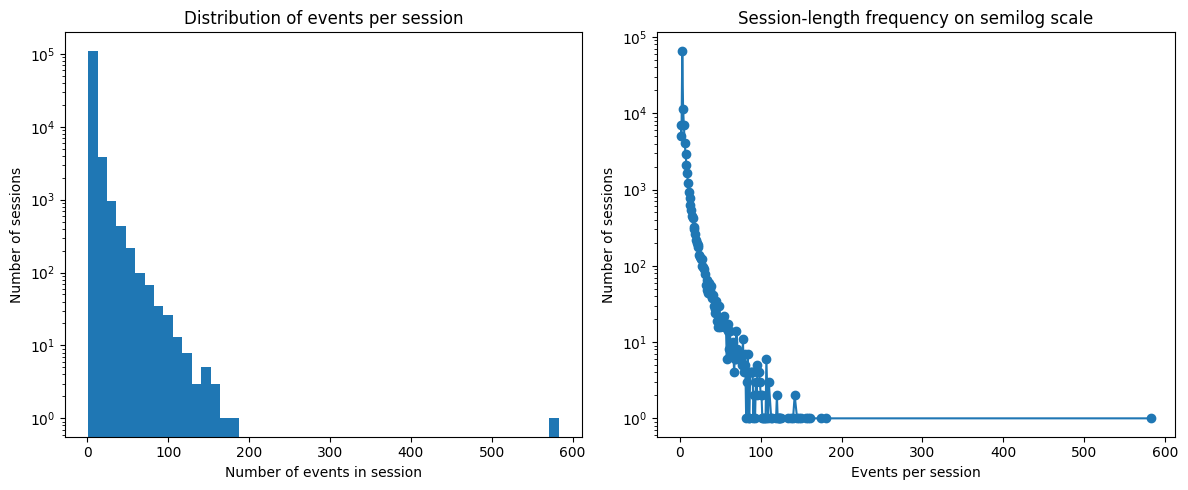

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(events_per_session, bins=50, log=True)
axes[0].set_xlabel("Number of events in session")
axes[0].set_ylabel("Number of sessions")
axes[0].set_title("Distribution of events per session")

axes[1].semilogy(counts.index, counts.values, marker="o", linestyle="-")
axes[1].set_xlabel("Events per session")
axes[1].set_ylabel("Number of sessions")
axes[1].set_title("Session-length frequency on semilog scale")
plt.tight_layout()
plt.show()

distribution is consistent with a heavily right-skewed, fast-decaying count distribution.

mass is concentrated near small event counts, so most users seem to interact only a few times per session.

small number of sessions have many events, meaning engagement is very uneven.

single session near ~575 events is suspicious. (anomaly)

middle part shows rough linearity, which is compatible with approximately exponential decay in part of the body.

In [6]:
print("Summary statistics for events per session:")
print(events_per_session.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

# kind of a pragmatic threshold, only meant for exploratory purposes
events_per_session_without_outliers = events_per_session.drop(
                                        events_per_session[events_per_session > 200].index,
                                        inplace=False
                                    ).copy()
print("Summary statistics for events per session (without outliers):")
print(events_per_session_without_outliers.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

Summary statistics for events per session:
count    116092.000000
mean          4.729180
std           6.437712
min           1.000000
50%           3.000000
75%           4.000000
90%           8.000000
95%          12.000000
99%          31.000000
max         583.000000
dtype: float64
Summary statistics for events per session (without outliers):
count    116091.000000
mean          4.724199
std           6.209990
min           1.000000
50%           3.000000
75%           4.000000
90%           8.000000
95%          12.000000
99%          31.000000
max         181.000000
dtype: float64


removed only one obviously extreme point

the percentiles stayed exactly the same up to the 99th percentile

the shape of the distribution is therefore not being driven by that one outlier

var ~6.43^2 = 41.34 is much larger than the mean = 4.729 (even after extreme value deletion) -> therefore poisson is not a good model

In [7]:
x = np.sort(events_per_session_without_outliers.values)
ccdf = 1 - np.arange(1, len(events_per_session_without_outliers) + 1) / len(x) # complementary cumulative distribution function

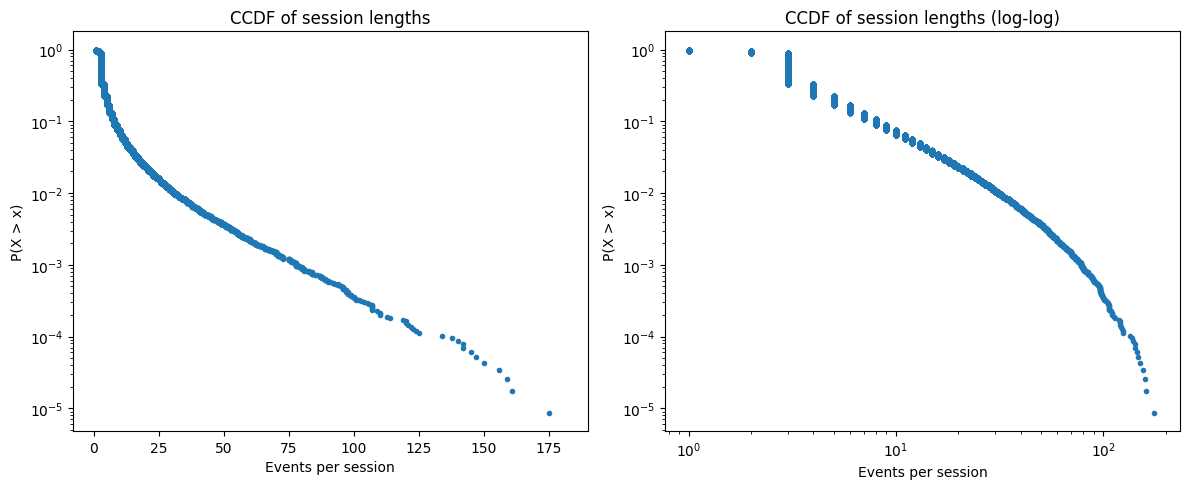

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].semilogy(x, ccdf, marker="o", linestyle="none", markersize=3)
axes[0].set_xlabel("Events per session")
axes[0].set_ylabel("P(X > x)")
axes[0].set_title("CCDF of session lengths")

axes[1].loglog(x, ccdf, marker="o", linestyle="none", markersize=3)
axes[1].set_xlabel("Events per session")
axes[1].set_ylabel("P(X > x)")
axes[1].set_title("CCDF of session lengths (log-log)")
plt.tight_layout()
plt.show()

semilog CCDF is curved, not straight, the hole distribution is not consistent with a single constant-rate decay process.

log-log CCDF is curved downward, not linear, therefore no pure power law.

suggests that an overdispersed count model, such as the negative binomial or a mixture of geometric-like processes is more appropriate

In [9]:
ecom_df["event"].value_counts()

event
product_list_view       142171
main                    116599
session_start           115953
product_view             77665
store_page               23626
basket                   18455
add_to_cart              15180
sign_in                   8676
search                    8154
view_search_results       7581
account_page              3896
shipping_details          3818
payment_details           2798
registration              1801
purchase                  1182
wishlist_page              344
registration_page          327
forgot_password_page       253
store_item_page            245
review_order               223
reset_password_page         64
view_item_list               9
Name: count, dtype: int64

In [10]:
events_mapping = { # event name to event id mapping, trying to be match logical flow of an e-commerce website
    "session_start": 0,
    "main": 1,
    "sign_in": 2,
    "registration_page": 3,
    "registration": 4,
    "forgot_password_page": 5,
    "reset_password_page": 6,
    "account_page": 7,
    "product_list_view": 8,
    "search": 9,
    "view_search_results": 10,
    "store_page": 11,
    "store_item_page": 12,
    "view_item_list": 13,
    "product_view": 14,
    "wishlist_page": 15,
    "add_to_cart": 16,
    "basket": 17,
    "shipping_details": 18,
    "payment_details": 19,
    "review_order": 20,
    "purchase": 21,
}

In [11]:
sessions_df = (
    ecom_df
        .sort_values(
            [
                "session_id",
                "event_order", 
                "timestamp"
            ]
        )
        .assign(
            event_idx=lambda d: d.groupby("session_id").cumcount()
        )
        .drop_duplicates(subset=["timestamp"])
        .pipe(
                lambda d: d.pivot(index="session_id", columns="event_idx", values="event")
                        .add_prefix("event_")
                        .join(d.groupby("session_id")["is_old_user"].first())
                        .reset_index()
                        .rename_axis(None, axis=1)
        )
)

sessions_df.shape

(116092, 585)

In [12]:
event_cols = (
    sessions_df
        .columns
        .copy()
        .delete([0, -1]) # drop session_id, is_old_user
)

session_event_seq = (
    sessions_df[event_cols]
        .apply(
            lambda row: [
                events_mapping.get(event) 
                for event in row.dropna().tolist()
            ],
            axis=1
        )
)

transition_counts = np.zeros((len(events_mapping), len(events_mapping)), dtype=np.float64)

for seq in session_event_seq:
    for a, b in zip(seq[:-1], seq[1:]):
        transition_counts[a, b] += 1

sums_per_row = transition_counts.sum(axis=1, keepdims=True)
transition_prob_mat = np.divide(transition_counts,
                                sums_per_row,
                                out=np.zeros_like(transition_counts),
                                where=sums_per_row != 0)

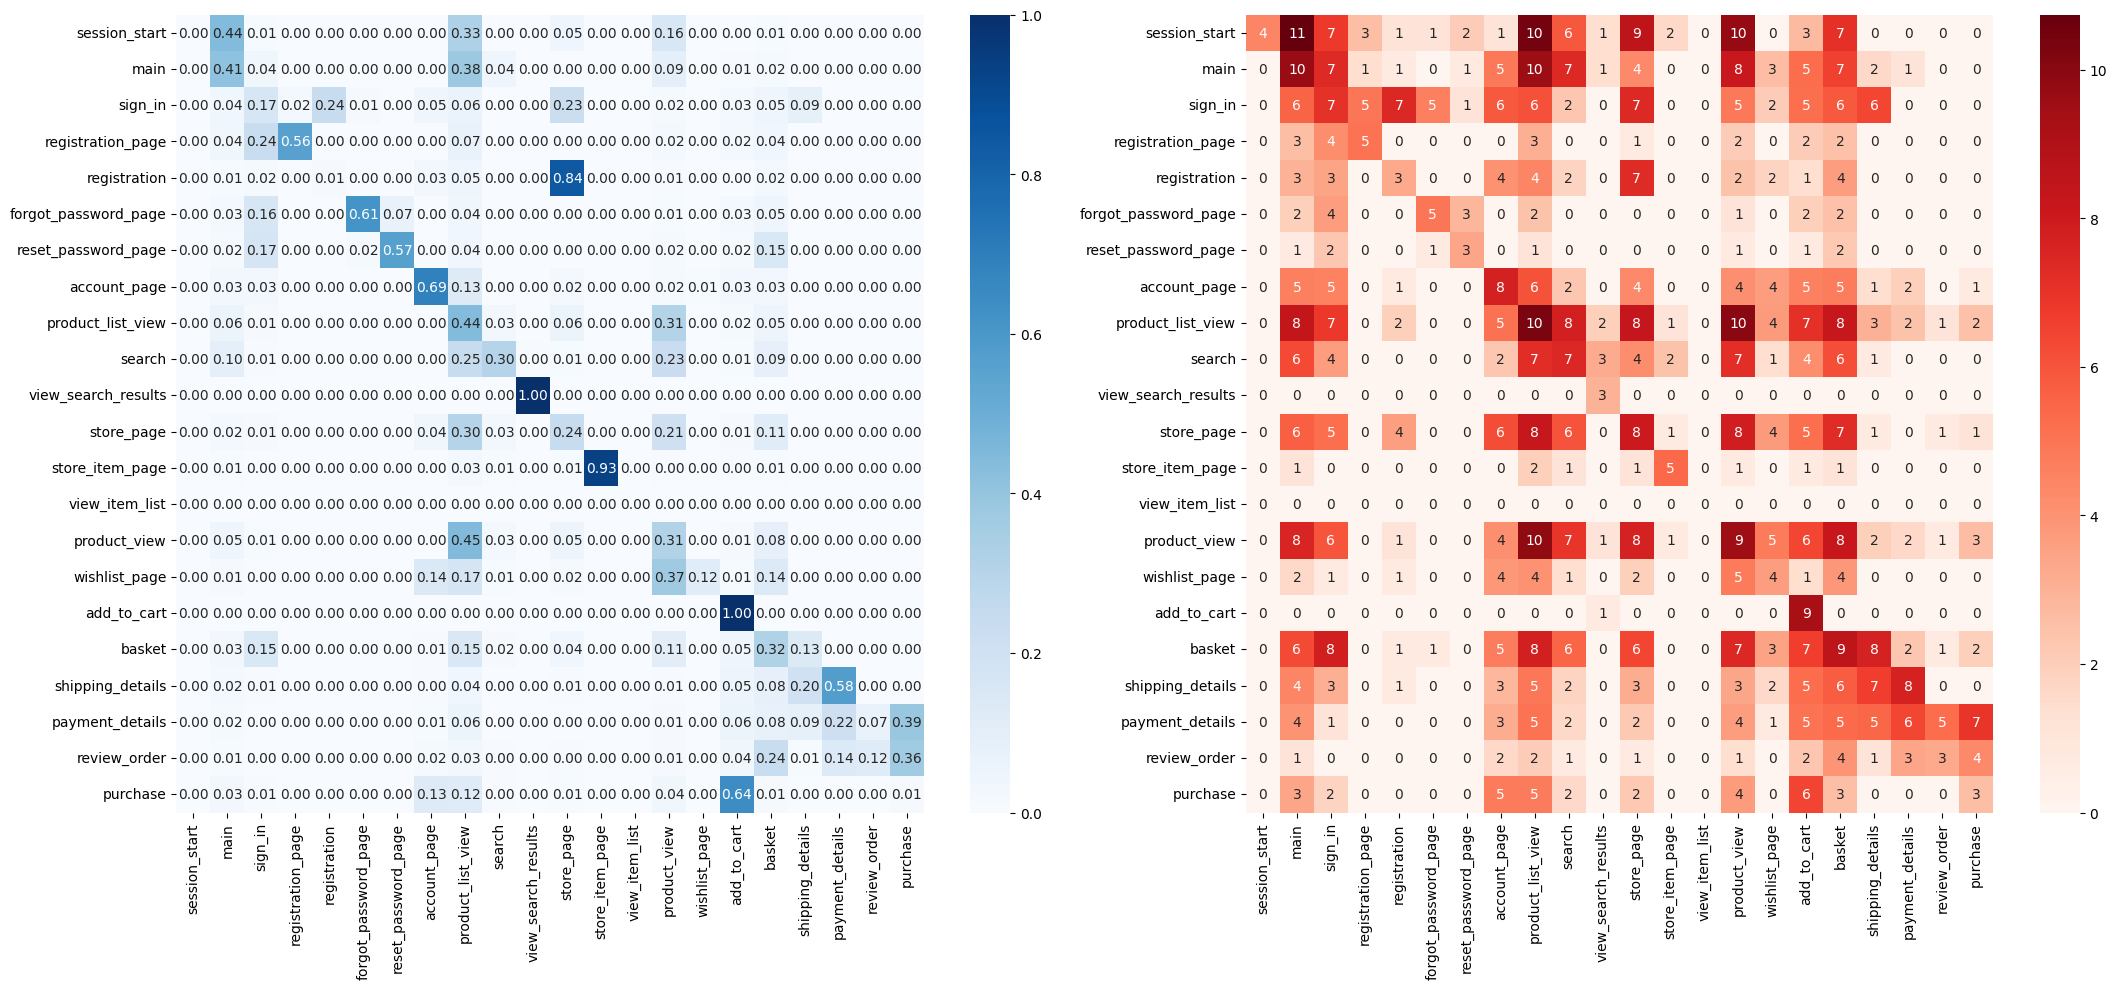

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
sns.heatmap(transition_prob_mat, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=events_mapping.keys(), yticklabels=events_mapping.keys(), ax=axes[0])
sns.heatmap(np.log1p(transition_counts), annot=True, fmt=".0f", cmap="Reds", # log1p to better visualize
            xticklabels=events_mapping.keys(), yticklabels=events_mapping.keys(), ax=axes[1])
plt.tight_layout()
plt.show()